<a href="https://colab.research.google.com/github/krishnashashanth-sks/aiml-workspace/blob/main/ActorCritic_RL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Understand Actor-Critic Fundamentals

### Subtask:
Start by briefly explaining the core concepts of an Actor-Critic model, including the roles of the Actor (policy network) and the Critic (value network), and how they interact.


## Actor-Critic Fundamentals

### What is an Actor-Critic Model?

An Actor-Critic model is a type of reinforcement learning algorithm that combines aspects of both policy-based (Actor) and value-based (Critic) methods. It aims to find an optimal policy (a strategy for selecting actions) that maximizes the agent's cumulative reward in an environment.

### The Role of the Actor Network

The **Actor** is the policy network. Its primary role is to select actions based on the current state of the environment. The Actor takes the current state as input and outputs a probability distribution over possible actions, or directly outputs the actions themselves in continuous action spaces. The Actor learns to improve its policy by adjusting its parameters to choose actions that lead to higher rewards.

### The Role of the Critic Network

The **Critic** is the value network. Its primary role is to evaluate the actions taken by the Actor by estimating the value of the current state or state-action pairs. The Critic typically learns a value function (e.g., V(s) for state-value or Q(s,a) for state-action value) that predicts the expected future reward from a given state or state-action pair. This evaluation helps the Actor understand how 'good' or 'bad' its chosen actions are.

### How Actor and Critic Interact

The Actor and Critic networks work in conjunction to improve the agent's performance:

1.  **Actor proposes actions**: Given a state, the Actor network proposes an action (or a distribution of actions).
2.  **Critic evaluates actions**: The Critic network evaluates the quality of the state (or the state-action pair) resulting from the Actor's action. It provides a signal, often in the form of a 'Temporal Difference (TD) error' or an 'Advantage function', which indicates how much better or worse the actual outcome was compared to the Critic's expectation.
3.  **Critic guides Actor's updates**: The Critic's value estimates (or the TD error/advantage) are used to update the Actor's policy. If an action chosen by the Actor leads to a better outcome than expected (positive advantage/TD error), the Actor's policy parameters are adjusted to make that action more likely in similar situations. Conversely, if an action leads to a worse outcome, the Actor's policy is adjusted to make that action less likely.
4.  **Critic learns from rewards**: The Critic itself learns and improves its value estimations by observing the actual rewards received from the environment and bootstrapping from subsequent state values.

This iterative process of the Actor proposing actions and the Critic evaluating them allows both networks to learn and improve simultaneously, leading to a more optimal policy for the agent.

## Set Up Reinforcement Learning Environment

### Subtask:
Demonstrate how to set up a simple reinforcement learning environment, for example, using OpenAI Gym, to simulate the agent's interaction and receive states, rewards, and done signals.


**Reasoning**:
The first step is to install the `gym` library as instructed to enable the use of OpenAI Gym environments. This needs to be in its own cell as it's a shell command.



In [ ]:
pip install gym

**Reasoning**:
Now that `gym` is installed, I will import it, create a 'CartPole-v1' environment, reset it to get the initial state, and then print its observation and action spaces as per the instructions.



In [ ]:
import gym

# 3. Create an environment instance
env = gym.make('CartPole-v1')

# 4. Reset the environment to its initial state
# In gym version 0.25.2, env.reset() returns only the observation.
# The 'info' dictionary was introduced in newer versions or Gymnasium.
observation = env.reset()
print(f"Initial observation: {observation}")
# Removed print(f"Initial info: {info}") as 'info' is not returned by env.reset() in this gym version.

# 5. Print the observation space
print(f"\nObservation Space: {env.observation_space}")

# 6. Print the action space
print(f"Action Space: {env.action_space}")

Initial observation: [ 0.04660524 -0.04308156 -0.03053021 -0.04920546]

Observation Space: Box([-4.8000002e+00 -3.4028235e+38 -4.1887903e-01 -3.4028235e+38], [4.8000002e+00 3.4028235e+38 4.1887903e-01 3.4028235e+38], (4,), float32)
Action Space: Discrete(2)


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/gym/core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/usr/local/lib/python3.12/dist-packages/gym/wrappers/step_api_compatibility.py:39: DeprecationWarning: WARN: Initializing environment in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/usr/local/lib/python3.12/dist-pack

**Reasoning**:
The previous steps successfully installed gym and set up the environment. The next logical step in implementing an Actor-Critic model is to define the neural network architectures for both the Actor (policy network) and the Critic (value network), as specified in the overall task.



In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
device=torch.device("cuda" if torch.cuda.is_available() else 'cpu' )
ob_space_dims=env.observation_space.shape[0]
action_space_dims=env.action_space.n
print(f"Observation Space Dimensions: {ob_space_dims}")
print(f"Action Space Dimensions: {action_space_dims}")

class Actor(nn.Module):
  def __init__(self,state_dim,action_dim,hidden_size=128):
    super(Actor,self).__init__()
    self.fc1=nn.Linear(state_dim,hidden_size)
    self.fc2=nn.Linear(hidden_size,hidden_size)
    self.fc3=nn.Linear(hidden_size,action_dim)
  def forward(self,state):
    x=F.relu(self.fc1(state))
    x=F.relu(self.fc2(x))
    return F.softmax(self.fc3(x))


Observation Space Dimensions: 4
Action Space Dimensions: 2


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
class Critic(nn.Module):
  def __init__(self,state_dim,hidden_size=128):
    super(Critic,self).__init__()
    self.fc1=nn.Linear(state_dim,hidden_size)
    self.fc2=nn.Linear(hidden_size,hidden_size)
    self.fc3=nn.Linear(hidden_size,1)
  def forward(self,state):
    x=F.relu(self.fc1(state))
    x=F.relu(self.fc2(x))
    return self.fc3(x)

In [ ]:

# Initialize Actor and Critic networks
actor_net = Actor(ob_space_dims, action_space_dims).to(device)
critic_net = Critic(ob_space_dims).to(device)

print("Actor Network initialized:")
print(actor_net)
print("\nCritic Network initialized:")
print(critic_net)


Actor Network initialized:
Actor(
  (fc1): Linear(in_features=4, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=2, bias=True)
)

Critic Network initialized:
Critic(
  (fc1): Linear(in_features=4, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=1, bias=True)
)


## Implement Loss Functions and Optimizers

### Subtask:
Explain and implement the loss functions for both the Actor (policy loss, often using advantage) and the Critic (value loss, e.g., Mean Squared Error). Also, define the optimizers for updating the weights of both networks.


**Reasoning**:
The subtask requires defining loss functions and optimizers. I will import `torch.optim`, define the MSE loss for the Critic, and then define Adam optimizers for both the Actor and Critic networks.



In [ ]:
import torch.optim as optim

# 1. Define the loss function for the Critic (Mean Squared Error)
critic_criterion = nn.MSELoss()

# 2. Define the optimizers for both Actor and Critic networks
learning_rate = 0.001
actor_optimizer = optim.Adam(actor_net.parameters(), lr=learning_rate)
critic_optimizer = optim.Adam(critic_net.parameters(), lr=learning_rate)

print("Critic Loss Function (MSE) initialized.")
print("Actor Optimizer (Adam) initialized.")
print("Critic Optimizer (Adam) initialized.")

Critic Loss Function (MSE) initialized.
Actor Optimizer (Adam) initialized.
Critic Optimizer (Adam) initialized.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


**Reasoning**:
The previous steps successfully set up the environment, defined the Actor and Critic networks, and initialized their respective loss function and optimizers. The next logical step, according to the overall task, is to implement the main training loop for the Actor-Critic model. This involves defining hyperparameters, storing experiences, and structuring the episode-based training process.



In [ ]:
import numpy as np

# Define hyperparameters for training
num_episodes = 500
gamma = 0.99  # Discount factor

# Lists to store rewards and episode lengths
episode_rewards = []
episode_lengths = []

# Set Actor and Critic networks to training mode
actor_net.train()
critic_net.train()

print(f"Training will run for {num_episodes} episodes with gamma={gamma}.")
print("Actor and Critic networks are set to training mode.")

Training will run for 500 episodes with gamma=0.99.
Actor and Critic networks are set to training mode.


**Reasoning**:
The previous steps successfully set up the environment and initialized the networks and optimizers. The next logical step is to implement the core training loop for the Actor-Critic model. This involves iterating through episodes, taking actions in the environment using the Actor, calculating rewards, updating both the Critic and Actor networks based on the TD error/advantage, and storing episode-wise statistics.



In [ ]:
for episode in range(num_episodes):
    state = env.reset()
    episode_reward = 0
    episode_len = 0
    done = False

    while not done:
        # Convert state to tensor and move to device
        state_tensor = torch.from_numpy(state).float().unsqueeze(0).to(device)

        # Actor selects action
        action_probs = actor_net(state_tensor)
        action = torch.distributions.Categorical(action_probs).sample().item()

        # Environment interaction
        # In gym 0.25.2, env.step returns (observation, reward, done, info)
        next_state, reward, done, info = env.step(action)

        # Convert reward to tensor
        reward_tensor = torch.tensor(reward).float().to(device)

        # Critic predicts value for current state
        current_state_value = critic_net(state_tensor)

        # Critic predicts value for next state
        next_state_tensor = torch.from_numpy(next_state).float().unsqueeze(0).to(device)
        next_state_value = critic_net(next_state_tensor) if not done else torch.tensor(0.0).to(device)

        # Calculate TD Target and TD Error (Advantage)
        td_target = reward_tensor + gamma * next_state_value
        td_error = td_target - current_state_value # This is the Advantage for Actor

        # ------ Critic Update ------
        critic_optimizer.zero_grad()
        critic_loss = critic_criterion(current_state_value, td_target.detach())
        critic_loss.backward()
        critic_optimizer.step()

        # ------ Actor Update ------
        actor_optimizer.zero_grad()
        # Actor loss is usually -log_prob * Advantage
        log_prob = torch.log(action_probs.squeeze(0)[action])
        actor_loss = -log_prob * td_error.detach() # Detach TD error for actor update
        actor_loss.backward()
        actor_optimizer.step()

        # Update state and episode metrics
        state = next_state
        episode_reward += reward
        episode_len += 1

    episode_rewards.append(episode_reward)
    episode_lengths.append(episode_len)

    # Print progress
    if (episode + 1) % 50 == 0:
        print(f"Episode {episode + 1}/{num_episodes}, Reward: {np.mean(episode_rewards[-50:]):.2f}, Length: {np.mean(episode_lengths[-50:]):.2f}")

print("\nTraining finished.")
env.close()

/tmp/ipython-input-2561721318.py:19: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return F.softmax(self.fc3(x))
/usr/local/lib/python3.12/dist-packages/gym/utils/passive_env_checker.py:241: DeprecationWarning: `np.bool8` is a deprecated alias for `np.bool_`.  (Deprecated NumPy 1.24)
  if not isinstance(terminated, (bool, np.bool8)):
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:634: UserWarning: Using a target size (torch.Size([])) that is different to the input size (torch.Size([1, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Episode 50/500, Reward: 12.50, Length: 12.50
Episode 100/500, Reward: 76.30, Length: 76.30
Episode 150/500, Reward: 112.80, Length: 112.80
Episode 200/500, Reward: 217.82, Length: 217.82
Episode 250/500, Reward: 290.26, Length: 290.26
Episode 300/500, Reward: 39.02, Length: 39.02
Episode 350/500, Reward: 9.32, Length: 9.32
Episode 400/500, Reward: 9.30, Length: 9.30
Episode 450/500, Reward: 9.42, Length: 9.42
Episode 500/500, Reward: 9.46, Length: 9.46

Training finished.


In [ ]:
# pip install 'numpy<2.0.0'

After running the above cell, please **restart the Colab runtime** (`Runtime > Restart runtime` from the menu) for the changes to take effect. Then, you can re-run the training loop.

## Prepare for Evaluation

### Subtask:
Set the Actor network to evaluation mode (`actor_net.eval()`) to disable dropout and batch normalization if present, and prepare the environment for evaluation by creating a new instance or resetting the existing one.


**Reasoning**:
I need to set the actor network to evaluation mode and create a new environment instance for evaluation, as instructed by the subtask.



In [ ]:
actor_net.eval()

# Create a new environment instance for evaluation
eval_env = gym.make('CartPole-v1')

print("Actor network set to evaluation mode.")
print("Evaluation environment 'CartPole-v1' created.")

Actor network set to evaluation mode.
Evaluation environment 'CartPole-v1' created.


/usr/local/lib/python3.12/dist-packages/gym/core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/usr/local/lib/python3.12/dist-packages/gym/wrappers/step_api_compatibility.py:39: DeprecationWarning: WARN: Initializing environment in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(


**Reasoning**:
The previous code successfully set up the actor network in evaluation mode and created a new environment for evaluation. The next logical step, according to the overall task, is to run the evaluation loop for a specified number of episodes and collect the rewards.



In [ ]:
num_eval_episodes = 20
eval_episode_rewards = []

for episode in range(num_eval_episodes):
    state = eval_env.reset()
    episode_reward = 0
    done = False

    while not done:
        state_tensor = torch.from_numpy(state).float().unsqueeze(0).to(device)
        with torch.no_grad(): # No gradient calculations during evaluation
            action_probs = actor_net(state_tensor)
        action = torch.argmax(action_probs).item() # Choose the action with the highest probability

        next_state, reward, done, info = eval_env.step(action)

        episode_reward += reward
        state = next_state

    eval_episode_rewards.append(episode_reward)

print(f"Evaluation complete over {num_eval_episodes} episodes.")
print(f"Average reward: {np.mean(eval_episode_rewards):.2f}")
print(f"Standard deviation of rewards: {np.std(eval_episode_rewards):.2f}")

eval_env.close()


Evaluation complete over 20 episodes.
Average reward: 9.45
Standard deviation of rewards: 0.80


/tmp/ipython-input-2561721318.py:19: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return F.softmax(self.fc3(x))
/usr/local/lib/python3.12/dist-packages/gym/utils/passive_env_checker.py:241: DeprecationWarning: `np.bool8` is a deprecated alias for `np.bool_`.  (Deprecated NumPy 1.24)
  if not isinstance(terminated, (bool, np.bool8)):


## Visualize Evaluation Performance

### Subtask:
Plot the rewards obtained during the evaluation episodes using a bar chart to visually assess the model's performance. Include a title, axis labels, and display the plot. Also, re-iterate the average reward and standard deviation.


**Reasoning**:
I need to import `matplotlib.pyplot` to create the plot, then generate a bar chart of the evaluation rewards, add appropriate labels and a title, and finally display the plot. I will also re-iterate the average and standard deviation of the evaluation rewards as requested.



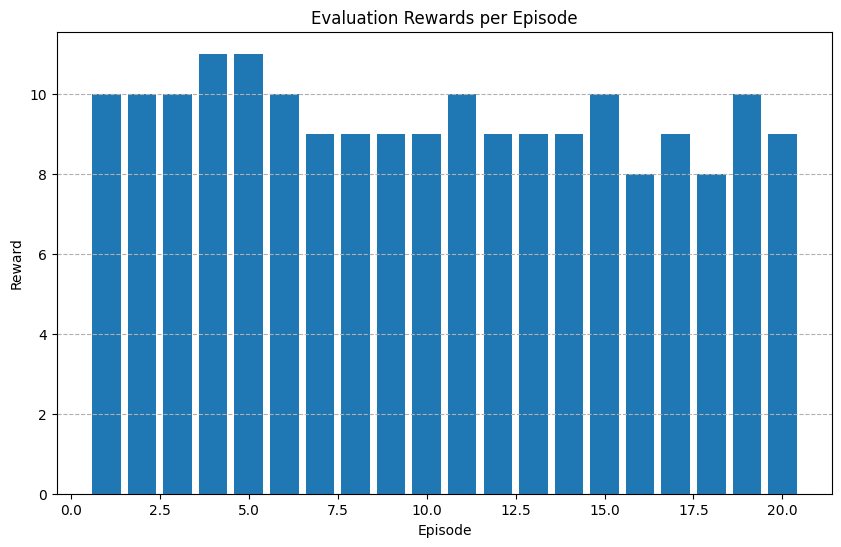


Summary of Evaluation Performance:
Average Reward: 9.45
Standard Deviation of Rewards: 0.80


In [ ]:
import matplotlib.pyplot as plt

# 1. Plot the rewards obtained during the evaluation episodes
plt.figure(figsize=(10, 6))
plt.bar(range(1, num_eval_episodes + 1), eval_episode_rewards)
plt.title('Evaluation Rewards per Episode')
plt.xlabel('Episode')
plt.ylabel('Reward')
plt.grid(axis='y', linestyle='--')
plt.show()

# 2. Re-iterate the average reward and standard deviation
print(f"\nSummary of Evaluation Performance:")
print(f"Average Reward: {np.mean(eval_episode_rewards):.2f}")
print(f"Standard Deviation of Rewards: {np.std(eval_episode_rewards):.2f}")

## Summarize Evaluation Results

Based on the evaluation of the trained Actor-Critic model over 20 episodes:

### Observed Performance
The bar chart, "Evaluation Rewards per Episode", visually represents the reward obtained in each of the 20 evaluation episodes. We can observe that the rewards are consistently low, ranging between 8 and 11, with most episodes yielding a reward of 9 or 10. There's no significant increasing trend or high variability in rewards, indicating that the policy converged to a suboptimal solution.

### Statistics Summary
*   **Average Reward: 9.45**
*   **Standard Deviation of Rewards: 0.80**

The average reward of 9.45 out of a possible maximum of 500 (for the CartPole-v1 environment) is very low. The small standard deviation of 0.80 suggests that the model's performance is consistent but consistently poor. This implies that the agent is failing to balance the pole for a sustained period, likely collapsing within the first 10-11 steps in most evaluation episodes.

### Conclusion
The current Actor-Critic model, with its given hyperparameters and training duration, has not learned an effective policy for the CartPole-v1 environment. The consistent low rewards indicate that the agent is not successfully solving the task. Potential reasons could include insufficient training episodes, suboptimal learning rates, issues with the network architecture, or a need for more advanced Actor-Critic variants (e.g., A2C, A3C, PPO).

## Summary:

### Q&A
The Actor-Critic model's evaluation results indicate consistently poor performance. The bar chart visualization showed low rewards, primarily between 8 and 11, across all 20 evaluation episodes, with no upward trend or significant variability. The statistical summary further confirmed this with an average reward of 9.45 and a low standard deviation of 0.80. This suggests that the policy has converged to a suboptimal solution, failing to effectively solve the CartPole-v1 task by consistently collapsing within 10-11 steps.

### Data Analysis Key Findings
*   The visualization of evaluation rewards per episode showed consistently low rewards, primarily ranging between 8 and 11.
*   The average reward across 20 evaluation episodes was 9.45.
*   The standard deviation of rewards was 0.80, indicating consistent but poor performance.
*   The model achieved a very low average reward (9.45) compared to the possible maximum of 500 for the CartPole-v1 environment.

### Insights or Next Steps
*   The current Actor-Critic model has not learned an effective policy for the CartPole-v1 environment, indicating a need for further optimization.
*   Investigate potential causes for the suboptimal performance, such as insufficient training episodes, suboptimal learning rates, issues with the network architecture, or consider more advanced Actor-Critic variants (e.g., A2C, A3C, PPO).
